In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
import urllib

In [2]:
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-5RVJNFO;"
    "DATABASE=ecommerce;"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

In [5]:
#Extract data from SQL Server
query = """
SELECT

c.customer_id,

o.order_id,

o.order_purchase_timestamp,

op.payment_value

FROM customers c

JOIN orders o
ON c.customer_id=o.customer_id

JOIN order_payments op
ON o.order_id=op.order_id
"""

In [6]:
df = pd.read_sql(query, engine)

df.head()

,customer_id,order_id,order_purchase_timestamp,payment_value
0,6a3b2fc9f270df258605e22bef19fd88,000e906b789b55f64edcb1f84030f90d,2017-11-21 18:54:23,33.84
1,eb729faa993caad20442243265804a7c,0045e3085f083f0f38d24bb3f22e6593,2017-08-10 16:13:36,130.74
2,cea80f9af87104810bd7fa9698f69d29,00c9f7d4b0e87781465e562dc109f6aa,2017-05-21 19:21:32,120.36
3,0d8111a81ce6ed7cb969e28a01392f63,00f1bb0af030935db1745ee28367ea26,2018-08-06 23:19:06,288.88
4,cba40225005628d0bb62cc9d15c9333f,010078e0913f48d014483bd856c01ca1,2017-11-26 14:52:03,58.61


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 4 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_id               103886 non-null  str           
 1   order_id                  103886 non-null  str           
 2   order_purchase_timestamp  103886 non-null  datetime64[us]
 3   payment_value             103886 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 3.2 MB


In [8]:
df.describe()

,order_purchase_timestamp,payment_value
count,103886,103886.000000
mean,2017-12-29 21:48:47.671803,154.100380
min,2016-09-04 21:15:19,0.000000
25%,2017-09-10 09:01:08.750000,56.790000
50%,2018-01-17 14:07:54,100.000000
75%,2018-05-03 18:35:58.250000,171.837500
max,2018-10-17 17:30:18,13664.080000
std,NaN,217.494064


In [9]:
#Convert Date Column
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

In [11]:
#Calculate Customer Revenue
customer_revenue = (
    df.groupby('customer_id')['payment_value']
      .sum()
      .reset_index()
)

customer_revenue.rename(
    columns={'payment_value':'Revenue'},
    inplace=True
)

customer_revenue.head()

,customer_id,Revenue
0,00012a2ce6f8dcda20d059ce98491703,114.74
1,000161a058600d5901f007fab4c27140,67.41
2,0001fd6190edaaf884bcaf3d49edf079,195.42
3,0002414f95344307404f0ace7a26f1d5,179.35
4,000379cdec625522490c315e70c7a9fb,107.01


In [12]:
#Calculate Number of Orders
customer_orders = (
    df.groupby('customer_id')['order_id']
      .nunique()
      .reset_index()
)

customer_orders.rename(
    columns={'order_id':'Orders'},
    inplace=True
)

customer_orders.head()

,customer_id,Orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [14]:
#Calculate Months Active
customer_dates = (
    df.groupby('customer_id')
      .agg(
          FirstPurchase=('order_purchase_timestamp','min'),
          LastPurchase=('order_purchase_timestamp','max')
      )
      .reset_index()
)

customer_dates.head()

,customer_id,FirstPurchase,LastPurchase
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,2017-11-14 16:08:26
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,2017-07-16 09:40:32
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,2017-02-28 11:06:43
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,2017-08-16 13:09:20
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,2018-04-02 13:42:17


In [15]:
#Difference in months between first and last purchase
customer_dates['MonthsActive'] = (
    customer_dates['LastPurchase']
    -
    customer_dates['FirstPurchase']
).dt.days/30

In [ ]:
#Avoid Division by Zero
customer_dates['MonthsActive'] = (
    customer_dates['MonthsActive']
    .replace(0,1)
)

In [19]:
#Merge All Tables
customer_metrics = customer_revenue.merge(
    customer_orders,
    on='customer_id'
)

customer_metrics = customer_metrics.merge(
    customer_dates[['customer_id','MonthsActive']],
    on='customer_id'
)

customer_metrics.head()

,customer_id,Revenue,Orders,MonthsActive
0,00012a2ce6f8dcda20d059ce98491703,114.74,1,1.0
1,000161a058600d5901f007fab4c27140,67.41,1,1.0
2,0001fd6190edaaf884bcaf3d49edf079,195.42,1,1.0
3,0002414f95344307404f0ace7a26f1d5,179.35,1,1.0
4,000379cdec625522490c315e70c7a9fb,107.01,1,1.0


In [21]:
#Average Order Value
customer_metrics['AverageOrderValue'] = (

    customer_metrics['Revenue']

    /

    customer_metrics['Orders']

)

In [22]:
#Purchase Frequency
customer_metrics['PurchaseFrequency'] = (

    customer_metrics['Orders']

    /

    customer_metrics['MonthsActive']

)

In [24]:
#Customer lifetime Value
customer_metrics['CLV'] = (

    customer_metrics['AverageOrderValue']

    *

    customer_metrics['PurchaseFrequency']

    *

    12

)

In [25]:
customer_metrics.head()

,customer_id,Revenue,Orders,MonthsActive,AverageOrderValue,PurchaseFrequency,CLV
0,00012a2ce6f8dcda20d059ce98491703,114.74,1,1.0,114.74,1.0,1376.88
1,000161a058600d5901f007fab4c27140,67.41,1,1.0,67.41,1.0,808.92
2,0001fd6190edaaf884bcaf3d49edf079,195.42,1,1.0,195.42,1.0,2345.04
3,0002414f95344307404f0ace7a26f1d5,179.35,1,1.0,179.35,1.0,2152.20
4,000379cdec625522490c315e70c7a9fb,107.01,1,1.0,107.01,1.0,1284.12


In [26]:
#Top 10 Customers
top10 = (

customer_metrics

.sort_values(

'CLV',

ascending=False

)

.head(10)

)

top10

,customer_id,Revenue,Orders,MonthsActive,AverageOrderValue,PurchaseFrequency,CLV
8546,1617b1357756262bfa56ab541c47bc16,13664.08,1,1.0,13664.08,1.0,163968.96
91984,ec5b2ba62e574342386871631fafd3fc,7274.88,1,1.0,7274.88,1.0,87298.56
77521,c6e2731c5b391845f6800c97401a43a9,6929.31,1,1.0,6929.31,1.0,83151.72
95123,f48d464a0baaea338cb25f816991ab1f,6922.21,1,1.0,6922.21,1.0,83066.52
24771,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,1,1.0,6726.66,1.0,80719.92
2065,05455dfa7cd02f13d132aa7a6a9729c6,6081.54,1,1.0,6081.54,1.0,72978.48
86907,df55c14d1476a9a3467f131269c2477f,4950.34,1,1.0,4950.34,1.0,59404.08
87396,e0a2412720e9ea4f26c1ac985f6a7358,4809.44,1,1.0,4809.44,1.0,57713.28
14282,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34,1,1.0,4764.34,1.0,57172.08
23932,3d979689f636322c62418b6346b1c6d2,4681.78,1,1.0,4681.78,1.0,56181.36


In [27]:
#Lowest CLV
customer_metrics.sort_values(

'CLV'

).head(10)

,customer_id,Revenue,Orders,MonthsActive,AverageOrderValue,PurchaseFrequency,CLV
64966,a73c1f73f5772cf801434bf984b0b1a7,0.00,1,1.0,0.00,1.0,0.00
20653,3532ba38a3fd242259a514ac2b6ae6b6,0.00,1,1.0,0.00,1.0,0.00
9908,197a2a6a77da93f678ea0d379f21da0a,0.00,1,1.0,0.00,1.0,0.00
65094,a790343ca6f3fee08112d678b43aa7c5,9.59,1,1.0,9.59,1.0,115.08
9456,184e8e8e48937145eb96c721ef1f0747,10.07,1,1.0,10.07,1.0,120.84
55144,8e4bd65db637116b6b68109e4df21b84,10.89,1,1.0,10.89,1.0,130.68
1742,046f890135acc703faff4c1fc0c2d73c,11.56,1,1.0,11.56,1.0,138.72
82106,d2c63ad286e3ca9dd69218008d61ff81,11.62,1,1.0,11.62,1.0,139.44
76589,c466c7e0ab222e3ef6c8046e96128a8d,11.63,1,1.0,11.63,1.0,139.56
33226,55cd7bfe95dcd698acf176278e14888e,11.63,1,1.0,11.63,1.0,139.56


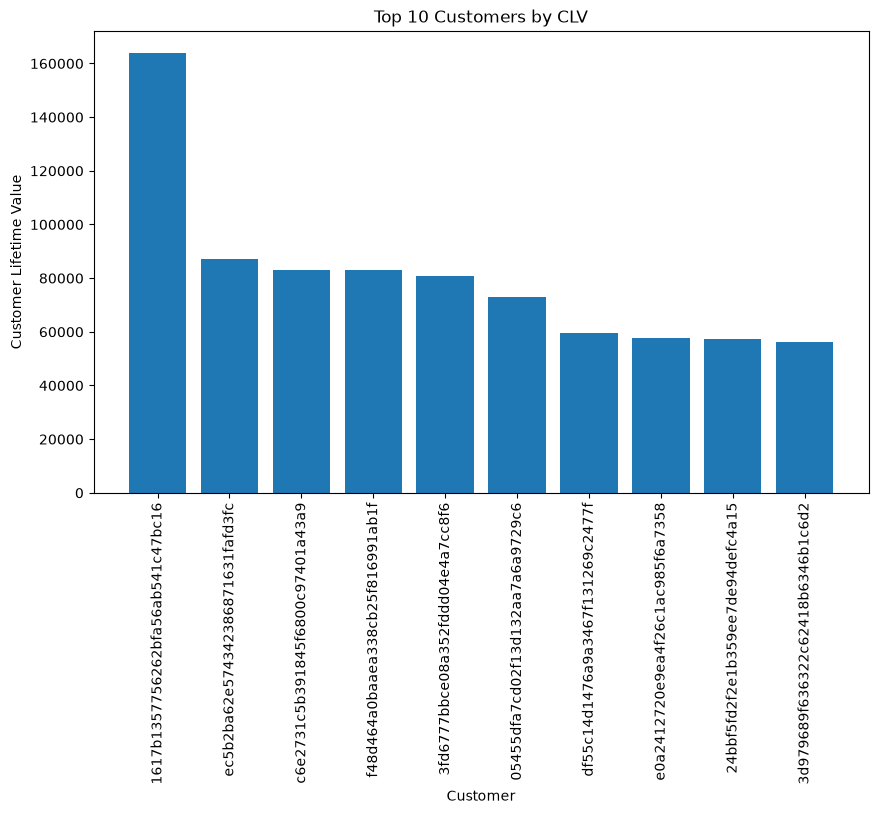

In [28]:
#Plot Top Customers
plt.figure(figsize=(10,6))

plt.bar(

top10['customer_id'],

top10['CLV']

)

plt.xticks(rotation=90)

plt.title("Top 10 Customers by CLV")

plt.xlabel("Customer")

plt.ylabel("Customer Lifetime Value")

plt.show()

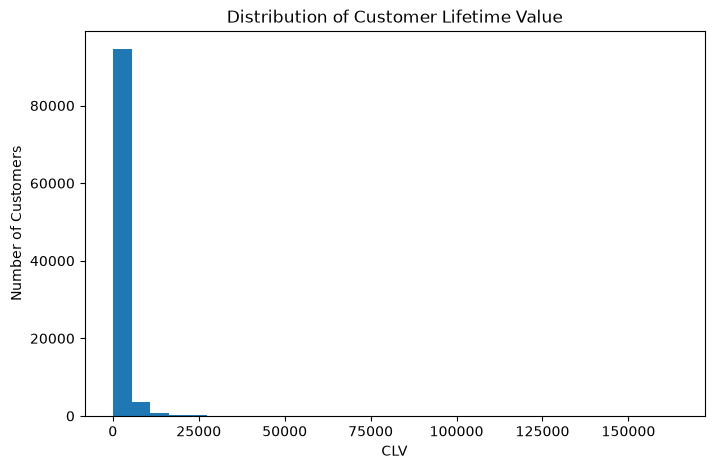

In [29]:
#CLV Distribution
plt.figure(figsize=(8,5))

plt.hist(

customer_metrics['CLV'],

bins=30

)

plt.title("Distribution of Customer Lifetime Value")

plt.xlabel("CLV")

plt.ylabel("Number of Customers")

plt.show()

In [30]:
customer_metrics.to_csv(
    "customer_clv.csv",
    index=False
)